In [10]:
from pathlib import Path

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent   # go up to project root

INPUT_FILE  = BASE_DIR / "data" / "processed" / "cleaned_retail_dataset.csv"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
import pandas as pd
# Load Data to Pandas Dataframe
retail_df = pd.read_csv(INPUT_FILE,
                       dtype = {'InvoiceNo': 'category' , 'StockCode':'category' , 'Description':'category' , 'Country':'category' })
# Print First Ten rows of the Dataset
retail_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,MonthNumber,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01,7.65,17850.0,United Kingdom,15.30,2010,12,December
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01,4.25,17850.0,United Kingdom,25.50,2010,12,December
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01,1.85,17850.0,United Kingdom,11.10,2010,12,December
8,536366,22632,HAND WARMER RED RETROSPOT,6,2010-12-01,1.85,17850.0,United Kingdom,11.10,2010,12,December
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01,1.69,13047.0,United Kingdom,54.08,2010,12,December


## Data Visualization & Insights

## 1). Monthly Sales Trend Analysis

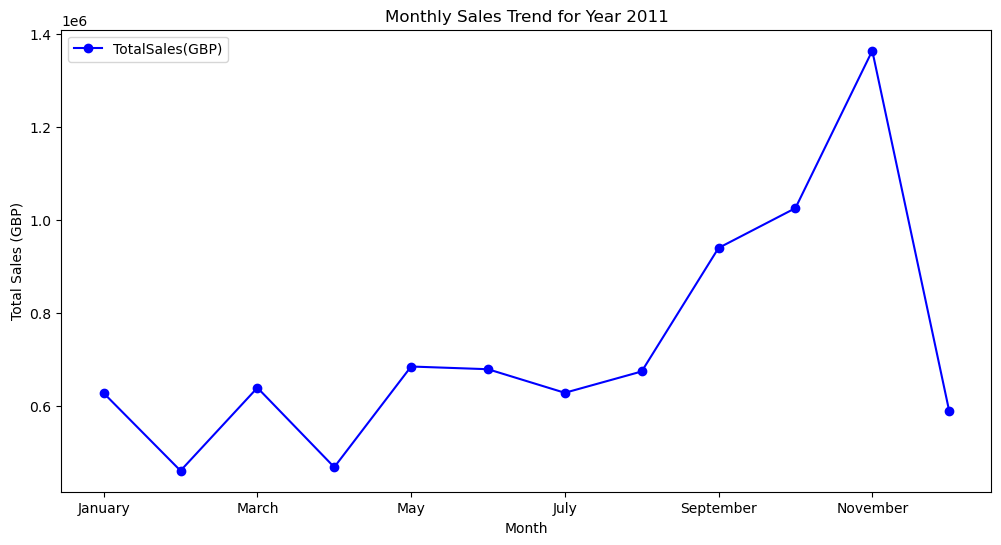

In [12]:
# Monthly Total Sales 
import matplotlib.pyplot as plt
df1 = retail_df[(retail_df['Year'] == 2011)][['Month' , 'MonthNumber' , 'TotalPrice']]
monthly_sales = df1.groupby(by = ['Month' , 'MonthNumber'])['TotalPrice'].sum().reset_index().sort_values(by = 'MonthNumber' , ascending = True)
monthly_sales.rename(columns={'TotalPrice': 'TotalSales(GBP)'}, inplace=True)
monthly_sales.plot(x = 'Month' , y = 'TotalSales(GBP)', kind ='line' , marker = 'o'  , color = 'blue' , figsize = (12 , 6))
plt.xlabel('Month')
plt.ylabel('Total Sales (GBP)')
plt.title('Monthly Sales Trend for Year 2011')
plt.show()

In [13]:
monthly_sales.to_csv(REPORTS_DIR  / "monthly_sales_2011.csv", index = False)

print('File save Succesfully!')

File save Succesfully!


## Insights
Total Sales Rising Up From August 2011 and have reached Peak in November 2011. This is likely due to Holiday season sales at end of the Year. 

## 2). Top 5 Country Based on Total Sales 

In [14]:
df2 = retail_df[(retail_df['Year'] == 2011)][['Country' , 'TotalPrice']]

country_wise_sales = df2.groupby(by = 'Country')['TotalPrice'].sum().reset_index().rename(columns = {'TotalPrice':'TotalSales(GBP)'})

top_5_country = country_wise_sales.sort_values(by = 'TotalSales(GBP)' , ascending = False).head(5)

top_5_country

,Country,TotalSales(GBP)
27,United Kingdom,7414895.44
7,EIRE,244144.74
19,Netherlands,237831.75
10,Germany,188385.71
9,France,175427.38


In [15]:
top_5_country.to_csv(REPORTS_DIR / "top_5_country_based_on_sales.csv", index = False)

print('File save succesfully!')

File save succesfully!


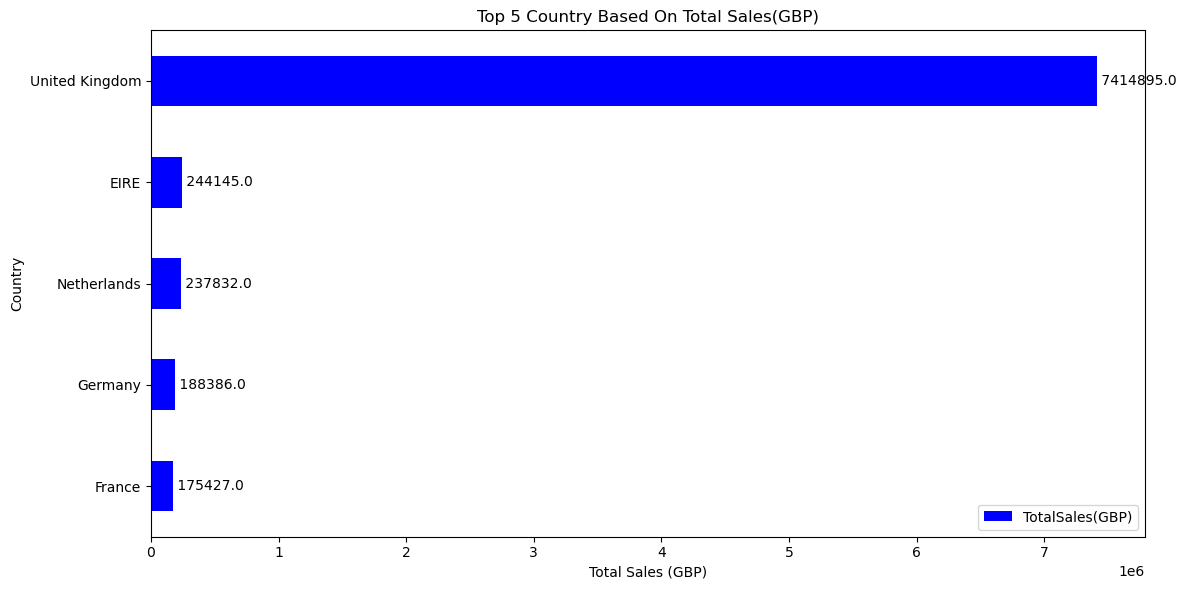

In [16]:
import matplotlib.pyplot as plt

# sort values
top_5_country.sort_values(by='TotalSales(GBP)', inplace=True)

# plot
ax = top_5_country.plot(
    x='Country',
    y='TotalSales(GBP)',
    kind='barh',
    color='blue',
    figsize=(12, 6),
    title='Top 5 Country Based On Total Sales(GBP)'
)

# add data labels (simple)
for i, v in enumerate(top_5_country['TotalSales(GBP)']):
    plt.text(v, i, " " + str(round(v, 0)), va='center')

# labels
plt.xlabel('Total Sales (GBP)')
plt.ylabel('Country')

# make layout tight
plt.tight_layout()

# show plot
plt.show()

## Insights

1). United Kingdom (UK) has total Sales around 8 Million GBP in 2011.

2). Other Four Countries (FIRE , Netherlands , Germany , France) having less than 1 millions GBP Sales each in 2011

Since These Countries Contruibute Major Sales Revenue we should pay special attention to customers of those countries and make sure our Product Quality and Service are best. Also break dependency of sales from one country we should focus on expanding our business to other countries as well.

## 3). Top 5 Country % Contribution of Total Sales

In [17]:
total_sales = country_wise_sales['TotalSales(GBP)'].sum()
top_5_country['Sales % Contribution'] = round( top_5_country['TotalSales(GBP)'] *100 / total_sales, 2)
top_5_country

,Country,TotalSales(GBP),Sales % Contribution
9,France,175427.38,2.00
10,Germany,188385.71,2.14
19,Netherlands,237831.75,2.71
7,EIRE,244144.74,2.78
27,United Kingdom,7414895.44,84.37


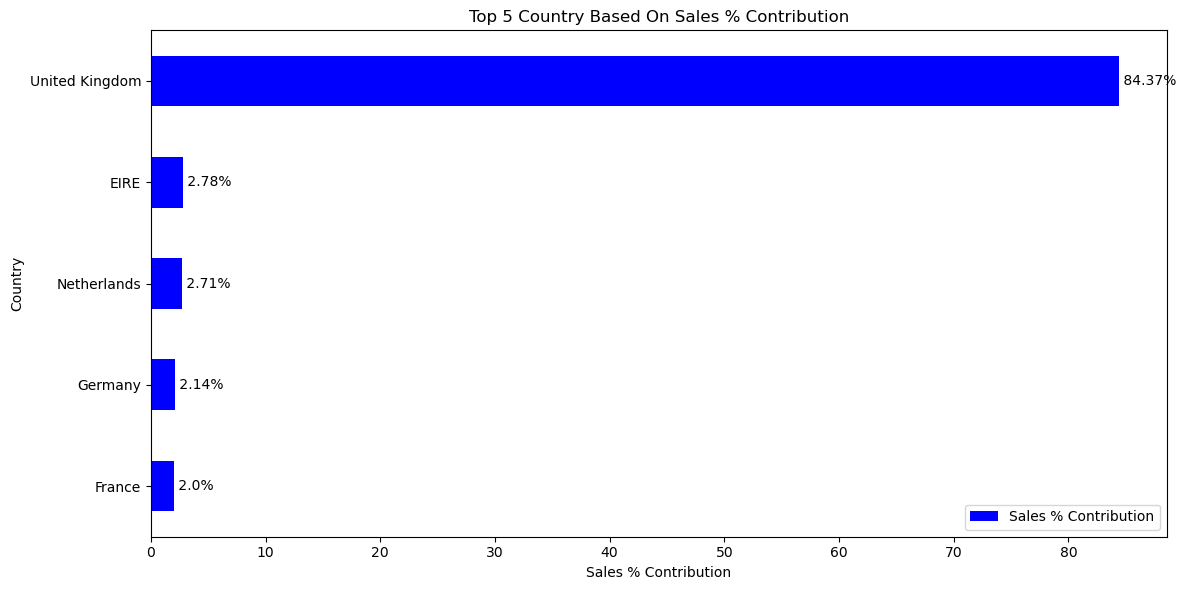

In [18]:
import matplotlib.pyplot as plt

# sort values
top_5_country.sort_values(by='Sales % Contribution', inplace=True)

# plot
ax = top_5_country.plot(
    x='Country',
    y='Sales % Contribution',
    kind='barh',
    color='blue',
    figsize=(12, 6),
    title='Top 5 Country Based On Sales % Contribution'
)

# add data labels (simple)
for i, v in enumerate(top_5_country['Sales % Contribution']):
    plt.text(v, i, " " + str(round(v, 2)) + "%", va='center')

# labels
plt.xlabel('Sales % Contribution')
plt.ylabel('Country')

# adjust layout
plt.tight_layout()

# show plot
plt.show()

## 4). Top Product 5 Based on Total Sales

In [19]:
df3 = retail_df[retail_df['Year'] == 2011][['Description' , 'TotalPrice']]

product_wise_sales = df3.groupby(by = 'Description')['TotalPrice'].sum().reset_index().rename(columns = {'TotalPrice':'TotalSales(GBP)'})

top_5_product = product_wise_sales.sort_values(by = 'TotalSales(GBP)'  , ascending = False).head(5)

top_5_product

,Description,TotalSales(GBP)
730,DOTCOM POSTAGE,181577.23
3427,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1899,REGENCY CAKESTAND 3 TIER,146461.78
1570,PARTY BUNTING,98237.49
2500,WHITE HANGING HEART T-LIGHT HOLDER,95181.01


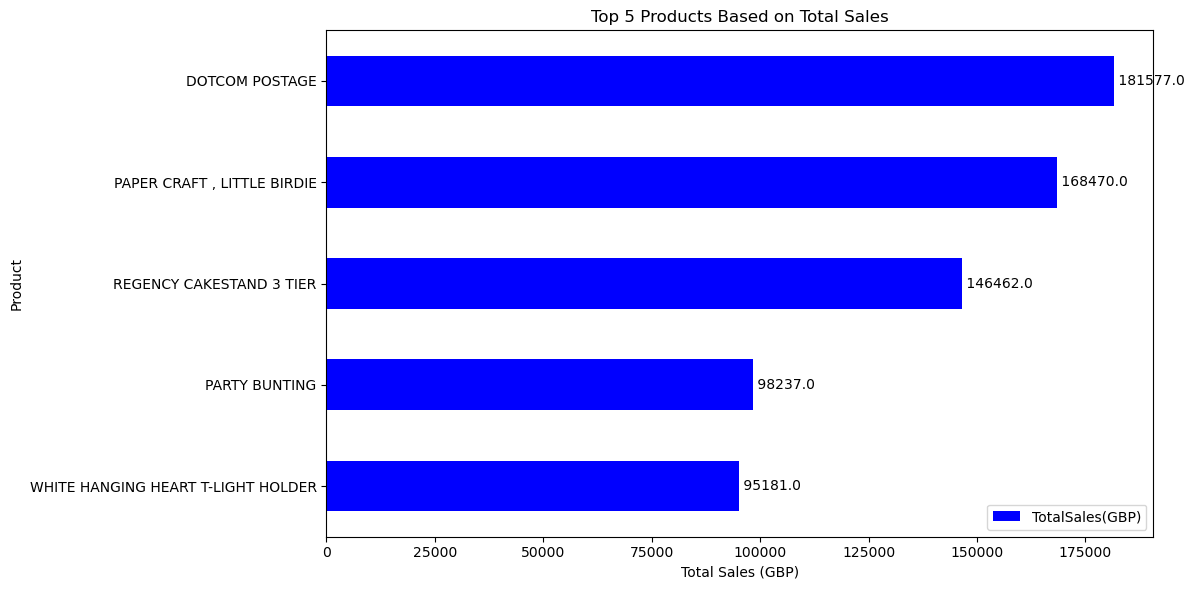

In [20]:
import matplotlib.pyplot as plt

# sort values
top_5_product.sort_values(by='TotalSales(GBP)', inplace=True)

# plot
ax = top_5_product.plot(
    x='Description',
    y='TotalSales(GBP)',
    kind='barh',
    color='blue',
    figsize=(12, 6),
    title='Top 5 Products Based on Total Sales'
)

# add data labels (simple)
for i, v in enumerate(top_5_product['TotalSales(GBP)']):
    plt.text(v, i, " " + str(round(v, 0)), va='center')

# labels
plt.xlabel('Total Sales (GBP)')
plt.ylabel('Product')

# keep everything inside
plt.tight_layout()

# show plot
plt.show()

## Insights

Top 5 Revenue-Generating Products in 2011 (GBP):

1).DOTCOM POSTAGE emerged as the highest revenue contributor, generating £181,577.23 in total sales.

2).PAPER CRAFT, LITTLE BIRDIE secured the second position with £168,469.60 in revenue.

3).REGENCY CAKESTAND 3 TIER ranked third, contributing £146,461.78 in total sales.

4).PARTY BUNTING held the fourth position with £98,237.49 in revenue.

5).WHITE HANGING HEART T-LIGHT HOLDER completed the top five, generating £95,181.01 in total sales.


## 5) Top 5 Product % Contribution of Total Sales

In [21]:
top_5_product['Sales % Contribution'] = round( top_5_product['TotalSales(GBP)'] * 100 / product_wise_sales['TotalSales(GBP)'].sum() , 2)

top_5_product

,Description,TotalSales(GBP),Sales % Contribution
2500,WHITE HANGING HEART T-LIGHT HOLDER,95181.01,1.08
1570,PARTY BUNTING,98237.49,1.12
1899,REGENCY CAKESTAND 3 TIER,146461.78,1.67
3427,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.92
730,DOTCOM POSTAGE,181577.23,2.07


In [22]:
top_5_product.to_csv(REPORTS_DIR / "top_5_product_based_on_sales.csv", index = False)

print('File Save Successffully!')

File Save Successffully!


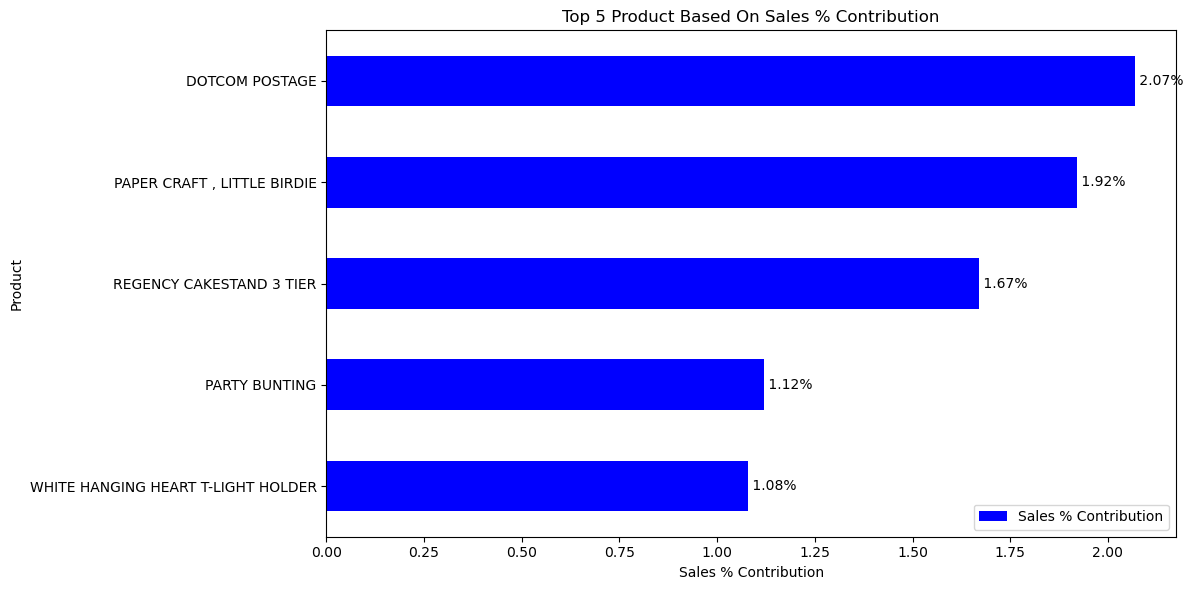

In [23]:
import matplotlib.pyplot as plt

# sort values
top_5_product.sort_values(by='Sales % Contribution', inplace=True)

# plot
ax = top_5_product.plot(
    x='Description',
    y='Sales % Contribution',
    kind='barh',
    color='blue',
    figsize=(12, 6),
    title='Top 5 Product Based On Sales % Contribution'
)

# add data labels (simple)
for i, v in enumerate(top_5_product['Sales % Contribution']):
    plt.text(v, i, " " + str(round(v, 2)) + "%", va='center')

# labels
plt.xlabel('Sales % Contribution')
plt.ylabel('Product')

# keep layout clean
plt.tight_layout()

# show plot
plt.show()

## 6). Top 5 Product Based on Quantity Sold

In [24]:
df4 = retail_df[(retail_df['Year'] == 2011)][['Description' , 'Quantity']]

product_wise_quantity_sold = df4.groupby(by = 'Description')['Quantity'].sum().reset_index().rename(columns = {'Quantity':'QuantitySold'})

top_5_high_demanding_product = product_wise_quantity_sold.sort_values(by = 'QuantitySold' , ascending = False).head(5)

top_5_high_demanding_product

,Description,QuantitySold
3427,"PAPER CRAFT , LITTLE BIRDIE",80995
1342,MEDIUM CERAMIC TOP STORAGE JAR,78033
1209,JUMBO BAG RED RETROSPOT,46220
2500,WHITE HANGING HEART T-LIGHT HOLDER,34063
160,ASSORTED COLOUR BIRD ORNAMENT,33999


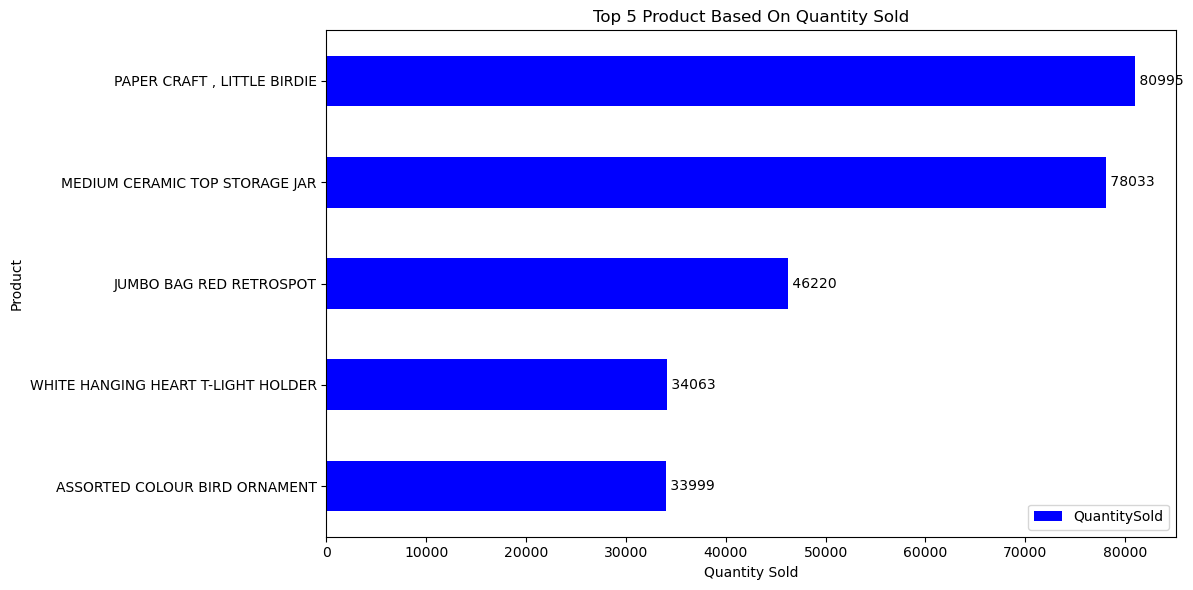

In [25]:
import matplotlib.pyplot as plt

# sort values
top_5_high_demanding_product.sort_values(by='QuantitySold', inplace=True)

#plot
ax = top_5_high_demanding_product.plot(
    x='Description',
    y='QuantitySold',
    kind='barh',
    color='blue',
    figsize=(12, 6),
    title='Top 5 Product Based On Quantity Sold'
)
# add data labels (simple)
for i, v in enumerate(top_5_high_demanding_product['QuantitySold']):
    plt.text(v, i, " " + str(round(v, 2)), va='center')


# labels    
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

# Keep Layout Clean
plt.tight_layout()

# show plot
plt.show()

### Top 5 Products by Quantity Sold in 2011

1). PAPER CRAFT, LITTLE BIRDIE leads significantly with 80,995 units sold, making it the most in-demand product in terms of volume.

2).MEDIUM CERAMIC TOP STORAGE JAR follows closely with 78,033 units, indicating strong and consistent customer demand.

3). JUMBO BAG RED RETROSPOT ranks third with 46,220 units, showing a noticeable drop compared to the top two products.

4). WHITE HANGING HEART T-LIGHT HOLDER records 34,063 units sold, maintaining steady mid-level demand.

5). ASSORTED COLOUR BIRD ORNAMENT rounds out the top five with 33,999 units, showing similar demand to the fourth-ranked product.

In [26]:
top_5_high_demanding_product.to_csv(REPORTS_DIR / "top_5_product_based_on_quantity_sold.csv" , index = False)

print('File Save Succesfully!')



File Save Succesfully!


### Final Business Recommendation


## Inventory Planning:
Prioritize stock availability for the top 2 products to avoid stockouts and lost sales.
## Bundling Strategy:
Combine mid-tier products with top-selling items to increase their sales volume.
## Pricing Optimization:
Analyze whether high-volume products have lower margins and explore pricing adjustments.
## Marketing Focus:
Promote top-performing products in campaigns since they already have proven demand.